In [1]:
print("KK")

KK


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Data generator for test set
# ==============================
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# ==============================
# Evaluate model
# ==============================
print("\n🧪 Evaluating model on test images...")
loss, accuracy = model.evaluate(test_generator, verbose=1)

# ==============================
# Print accuracy
# ==============================
print("\n===================================")
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
print(f"📉 Test Loss: {loss:.4f}")
print("===================================")


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



🧪 Evaluating model on test images...
36/36 ━━━━━━━━━━━━━━━━━━━━ 170s 5s/step - accuracy: 0.9680 - loss: 0.0919

✅ Test Accuracy: 96.80%
📉 Test Loss: 0.0919


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Evaluating model on test images...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9680 - loss: 0.0919 

✅ Overall Test Accuracy: 96.80%
📉 Test Loss: 0.0919

🔍 Generating predictions...
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step 

📊 Per-Class Accuracy:
algal_leaf_spot          : 96.00%
black_mold               : 99.20%
fruit_healthy            : 96.80%
healthy_leaf             : 88.80%
insect_bite              : 94.40%
red_rust                 : 99.20%
scab                     : 100.00%
scorch                   : 98.40%
yellow_leaf_disease      : 98.40%


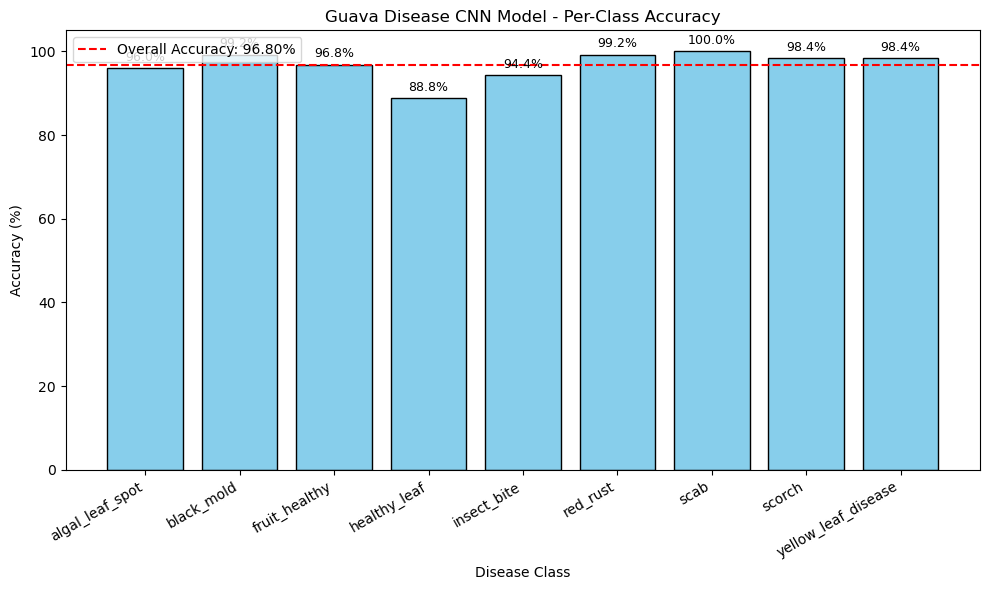

In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Data generator for test set
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# ==============================
# Evaluate model
# ==============================
print("\n🧪 Evaluating model on test images...")
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Overall Test Accuracy: {accuracy*100:.2f}%")
print(f"📉 Test Loss: {loss:.4f}")

# ==============================
# Predictions
# ==============================
print("\n🔍 Generating predictions...")
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ==============================
# Per-Class Accuracy
# ==============================
conf_mat = confusion_matrix(y_true, y_pred)
class_acc = conf_mat.diagonal() / conf_mat.sum(axis=1)

# ==============================
# Print Accuracy Table
# ==============================
print("\n📊 Per-Class Accuracy:")
for label, acc in zip(class_labels, class_acc):
    print(f"{label:25s}: {acc*100:.2f}%")

# ==============================
# Plot Accuracy Bar Chart
# ==============================
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, class_acc * 100, color='skyblue', edgecolor='black')
plt.axhline(y=accuracy * 100, color='red', linestyle='--', label=f"Overall Accuracy: {accuracy*100:.2f}%")
plt.xlabel("Disease Class")
plt.ylabel("Accuracy (%)")
plt.title("Guava Disease CNN Model - Per-Class Accuracy")
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()

# Add value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=9)

plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step 

📊 Creating Confusion Matrix...


<Figure size 1000x800 with 0 Axes>

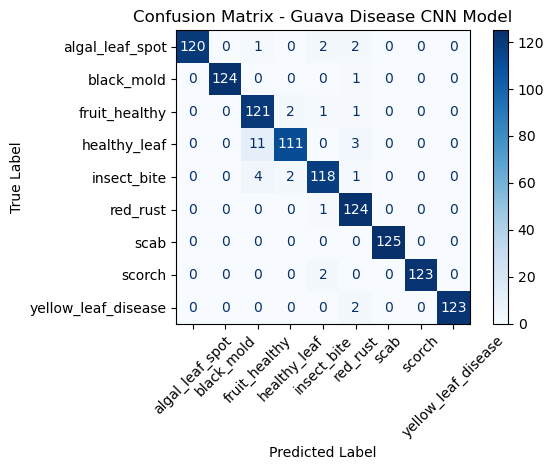

In [4]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# ==============================
# Predict and Evaluate
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# ==============================
# Confusion Matrix
# ==============================
print("\n📊 Creating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# ==============================
# Plot Confusion Matrix Figure
# ==============================
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix - Guava Disease CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step 


C:\Users\AIC\AppData\Local\Temp\ipykernel_9596\1687093972.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(probs_per_class, labels=class_labels, patch_artist=True)


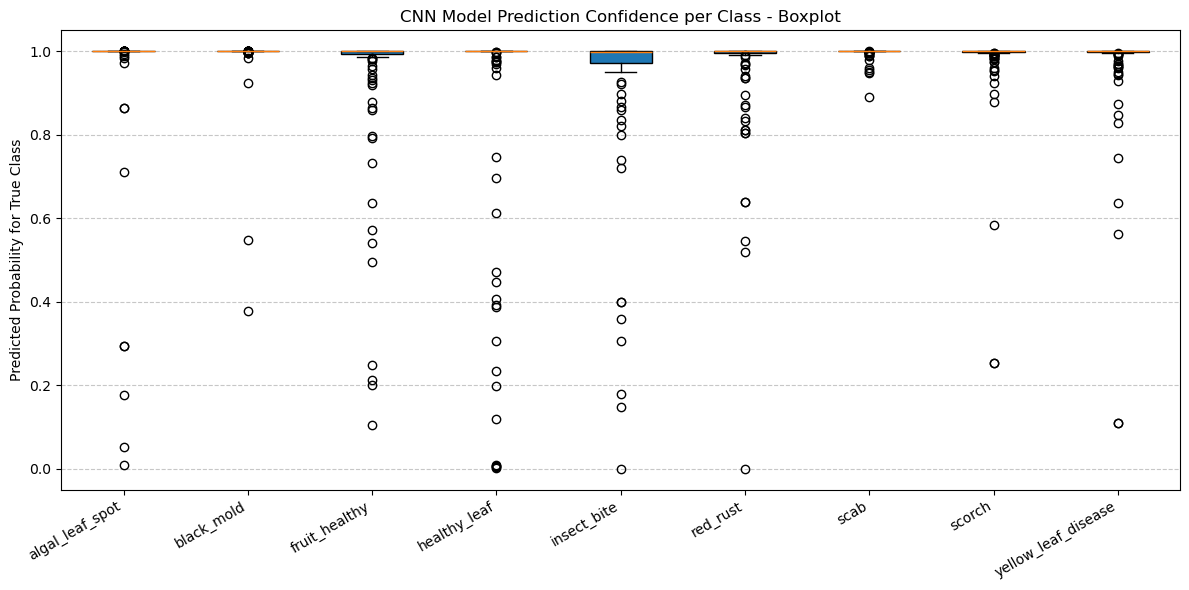

In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
num_classes = len(class_labels)

# ==============================
# Predict probabilities
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)  # shape: (num_images, num_classes)
y_true = test_generator.classes

# ==============================
# Organize probabilities per true class
# ==============================
probs_per_class = [[] for _ in range(num_classes)]
for i, true_label in enumerate(y_true):
    probs_per_class[true_label].append(preds[i, true_label])

# Convert to numpy arrays for boxplot
probs_per_class = [np.array(p) for p in probs_per_class]

# ==============================
# Plot Boxplot
# ==============================
plt.figure(figsize=(12, 6))
plt.boxplot(probs_per_class, labels=class_labels, patch_artist=True)
plt.xticks(rotation=30, ha='right')
plt.ylabel("Predicted Probability for True Class")
plt.title("CNN Model Prediction Confidence per Class - Boxplot")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step 


<Figure size 1000x800 with 0 Axes>

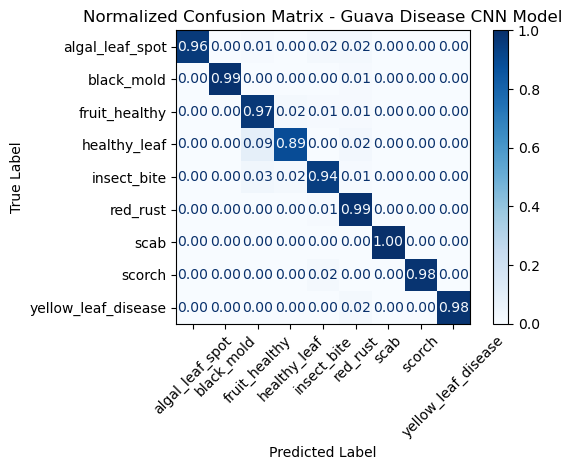

In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())

# ==============================
# Predict
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# ==============================
# Normalized Confusion Matrix
# ==============================
cm = confusion_matrix(y_true, y_pred, normalize='true')  # Normalize by row (true class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# ==============================
# Plot Normalized Confusion Matrix
# ==============================
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, colorbar=True, values_format=".2f")
plt.title("Normalized Confusion Matrix - Guava Disease CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step 


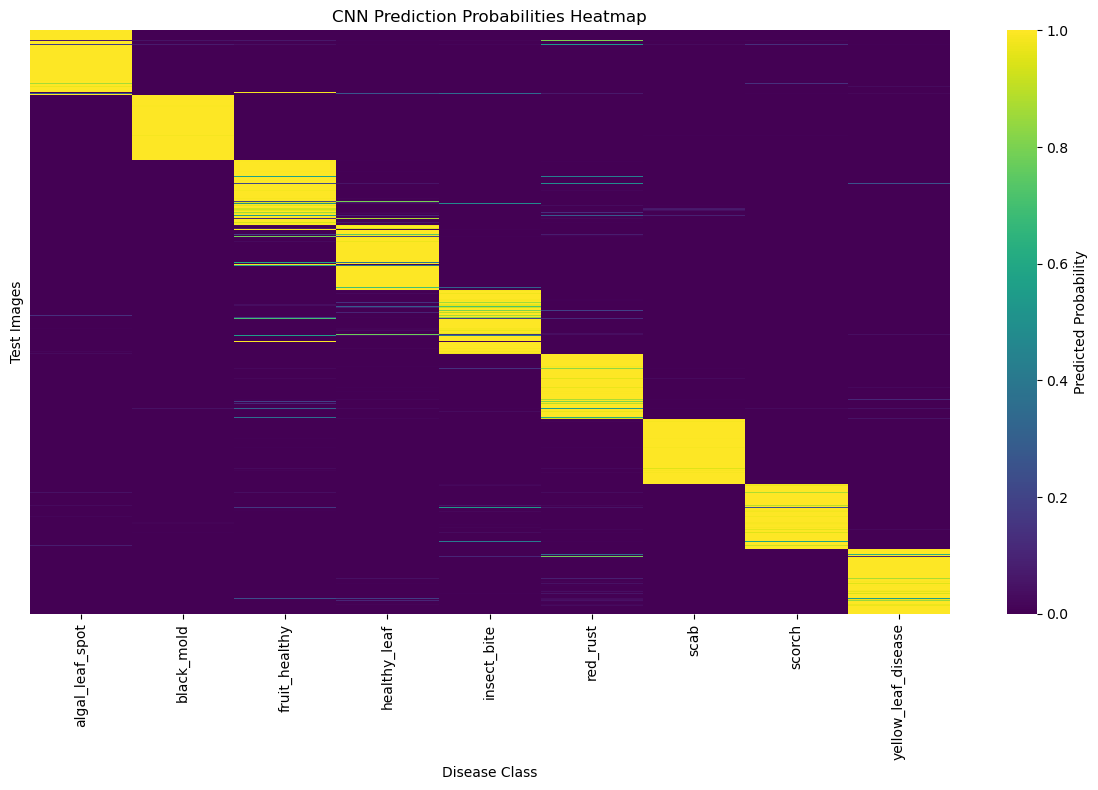

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
num_images = test_generator.samples

# ==============================
# Predict probabilities
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)  # shape: (num_images, num_classes)

# ==============================
# Plot Heatmap
# ==============================
plt.figure(figsize=(12, 8))
sns.heatmap(preds, cmap="viridis", xticklabels=class_labels, yticklabels=False, cbar_kws={'label': 'Predicted Probability'})
plt.title("CNN Prediction Probabilities Heatmap")
plt.xlabel("Disease Class")
plt.ylabel("Test Images")
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step 


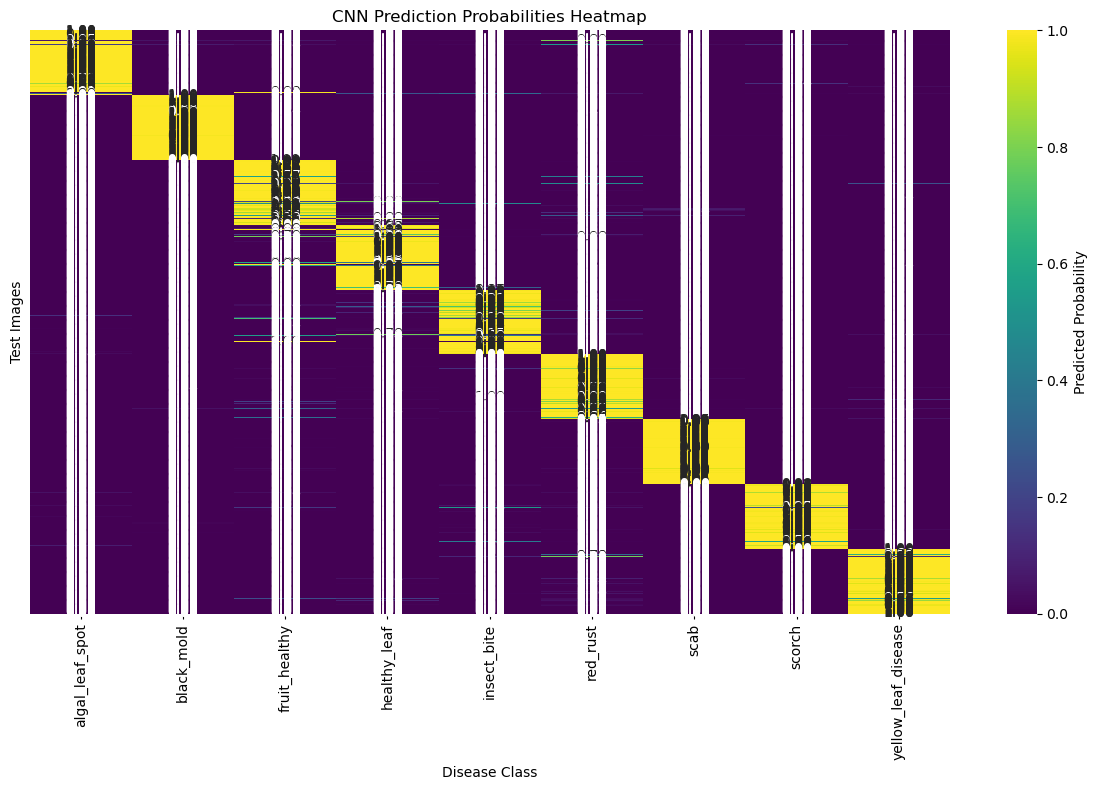

In [8]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
num_images = test_generator.samples

# ==============================
# Predict probabilities
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)  # shape: (num_images, num_classes)

# ==============================
# Plot Heatmap with Numbers
# ==============================
plt.figure(figsize=(12, 8))
sns.heatmap(preds, cmap="viridis", xticklabels=class_labels, yticklabels=False, 
            annot=np.round(preds, 2), fmt=".2f", cbar_kws={'label': 'Predicted Probability'})
plt.title("CNN Prediction Probabilities Heatmap")
plt.xlabel("Disease Class")
plt.ylabel("Test Images")
plt.tight_layout()
plt.show()


In [9]:
import tensorflow as tf

# Load the model
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
model = tf.keras.models.load_model(model_path)

# Print model summary
print("🔹 CNN Model Summary:")
model.summary()


🔹 CNN Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 640, 640, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 640, 640, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 320, 320, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 320, 320, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 160, 160, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 160, 160, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 80, 80, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 80, 80, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 40, 40, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,475 (1.61 MB)

 Trainable params: 422,473 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step 


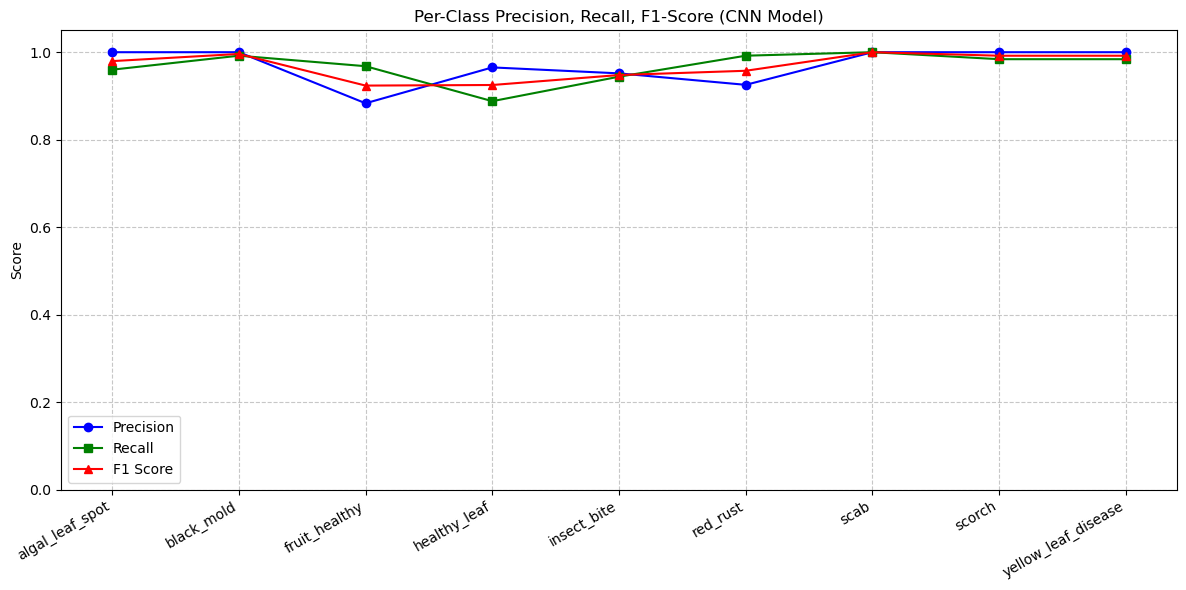

In [10]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())

# ==============================
# Predictions
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# ==============================
# Compute Metrics per Class
# ==============================
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

# ==============================
# Plot Curves
# ==============================
x = np.arange(len(class_labels))  # Class index

plt.figure(figsize=(12, 6))
plt.plot(x, precision_per_class, marker='o', label='Precision', color='blue')
plt.plot(x, recall_per_class, marker='s', label='Recall', color='green')
plt.plot(x, f1_per_class, marker='^', label='F1 Score', color='red')
plt.xticks(x, class_labels, rotation=30, ha='right')
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, F1-Score (CNN Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.

🧪 Generating predictions...


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step 


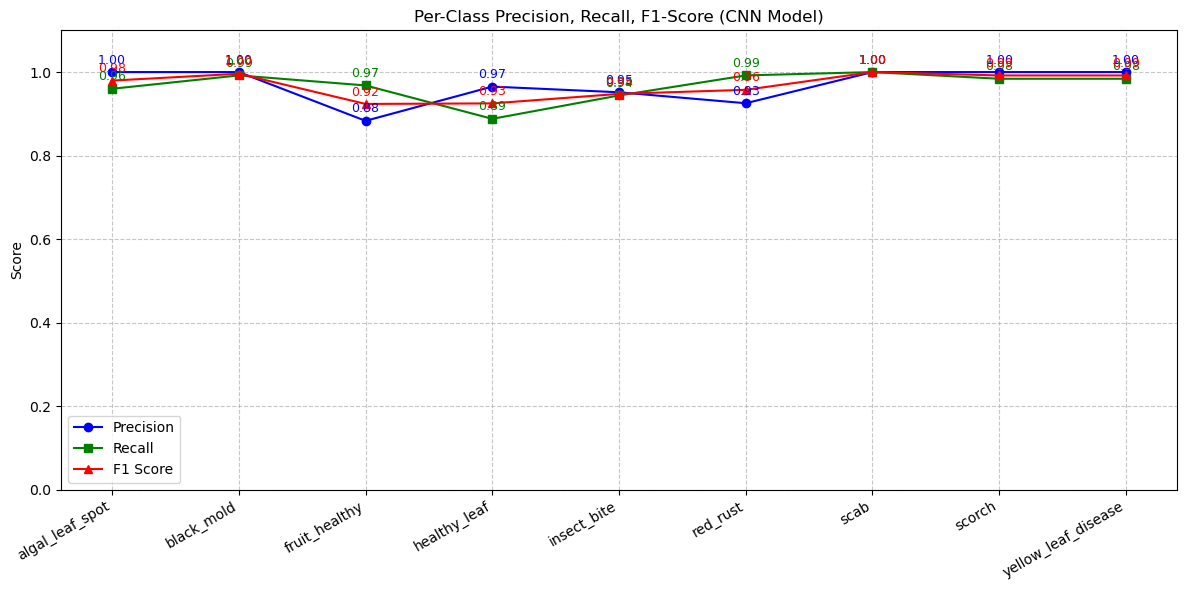

In [11]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())

# ==============================
# Predictions
# ==============================
print("\n🧪 Generating predictions...")
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# ==============================
# Compute Metrics per Class
# ==============================
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

# ==============================
# Plot Curves with Text
# ==============================
x = np.arange(len(class_labels))  # Class index

plt.figure(figsize=(12, 6))
plt.plot(x, precision_per_class, marker='o', label='Precision', color='blue')
plt.plot(x, recall_per_class, marker='s', label='Recall', color='green')
plt.plot(x, f1_per_class, marker='^', label='F1 Score', color='red')

# Annotate each point with value
for i in x:
    plt.text(i, precision_per_class[i]+0.02, f"{precision_per_class[i]:.2f}", color='blue', ha='center', fontsize=9)
    plt.text(i, recall_per_class[i]+0.02, f"{recall_per_class[i]:.2f}", color='green', ha='center', fontsize=9)
    plt.text(i, f1_per_class[i]+0.02, f"{f1_per_class[i]:.2f}", color='red', ha='center', fontsize=9)

plt.xticks(x, class_labels, rotation=30, ha='right')
plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, F1-Score (CNN Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [12]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640
batch_size = 32

# ==============================
# Load model
# ==============================
model = tf.keras.models.load_model(model_path)

# ==============================
# Prepare test data
# ==============================
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())

# ==============================
# Predictions
# ==============================
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

# ==============================
# Compute Metrics per Class
# ==============================
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

# ==============================
# Print Numeric Values
# ==============================
print("Class-wise Precision, Recall, F1-score:\n")
print(f"{'Class':25s} {'Precision':>10s} {'Recall':>10s} {'F1-score':>10s}")
print("="*60)
for label, p, r, f1 in zip(class_labels, precision_per_class, recall_per_class, f1_per_class):
    print(f"{label:25s} {p*100:9.2f}% {r*100:9.2f}% {f1*100:9.2f}%")

# Optional: Print macro averages
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')
print("\nMacro-Average Scores:")
print(f"Precision: {precision_macro*100:.2f}%, Recall: {recall_macro*100:.2f}%, F1-score: {f1_macro*100:.2f}%")


Found 1125 images belonging to 9 classes.


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step 
Class-wise Precision, Recall, F1-score:

Class                      Precision     Recall   F1-score
algal_leaf_spot              100.00%     96.00%     97.96%
black_mold                   100.00%     99.20%     99.60%
fruit_healthy                 88.32%     96.80%     92.37%
healthy_leaf                  96.52%     88.80%     92.50%
insect_bite                   95.16%     94.40%     94.78%
red_rust                      92.54%     99.20%     95.75%
scab                         100.00%    100.00%    100.00%
scorch                       100.00%     98.40%     99.19%
yellow_leaf_disease          100.00%     98.40%     99.19%

Macro-Average Scores:
Precision: 96.95%, Recall: 96.80%, F1-score: 96.82%


Found 1125 images belonging to 9 classes.


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step 


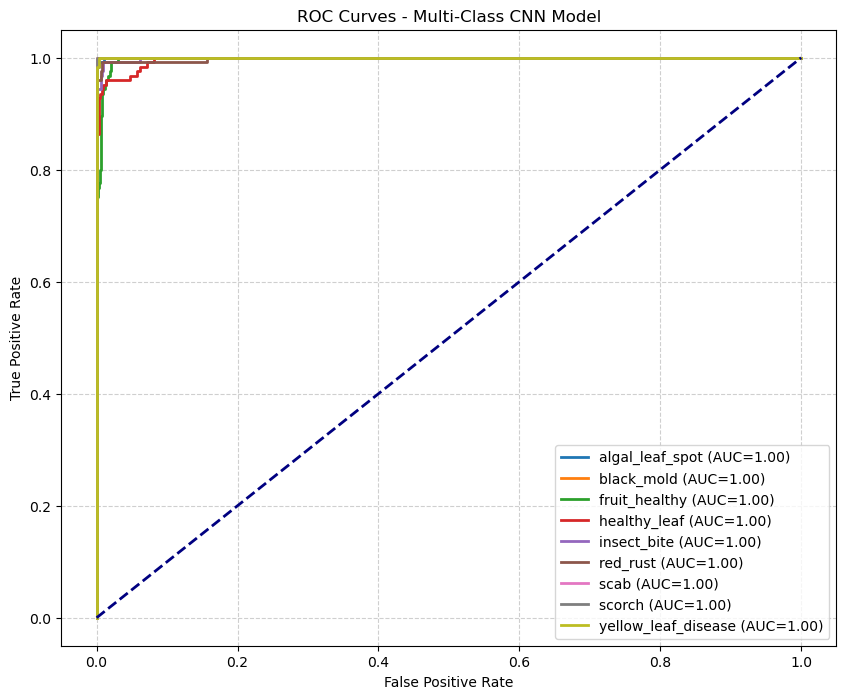

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Paths
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data\test"

# Parameters
img_height, img_width = 640, 640
batch_size = 32

# Load model
model = tf.keras.models.load_model(model_path)

# Prepare test data
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(test_generator.class_indices.keys())
num_classes = len(class_labels)

# Predictions
preds = model.predict(test_generator, verbose=1)
y_true = test_generator.classes
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot ROC for each class
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], preds[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_labels[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Multi-Class CNN Model")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


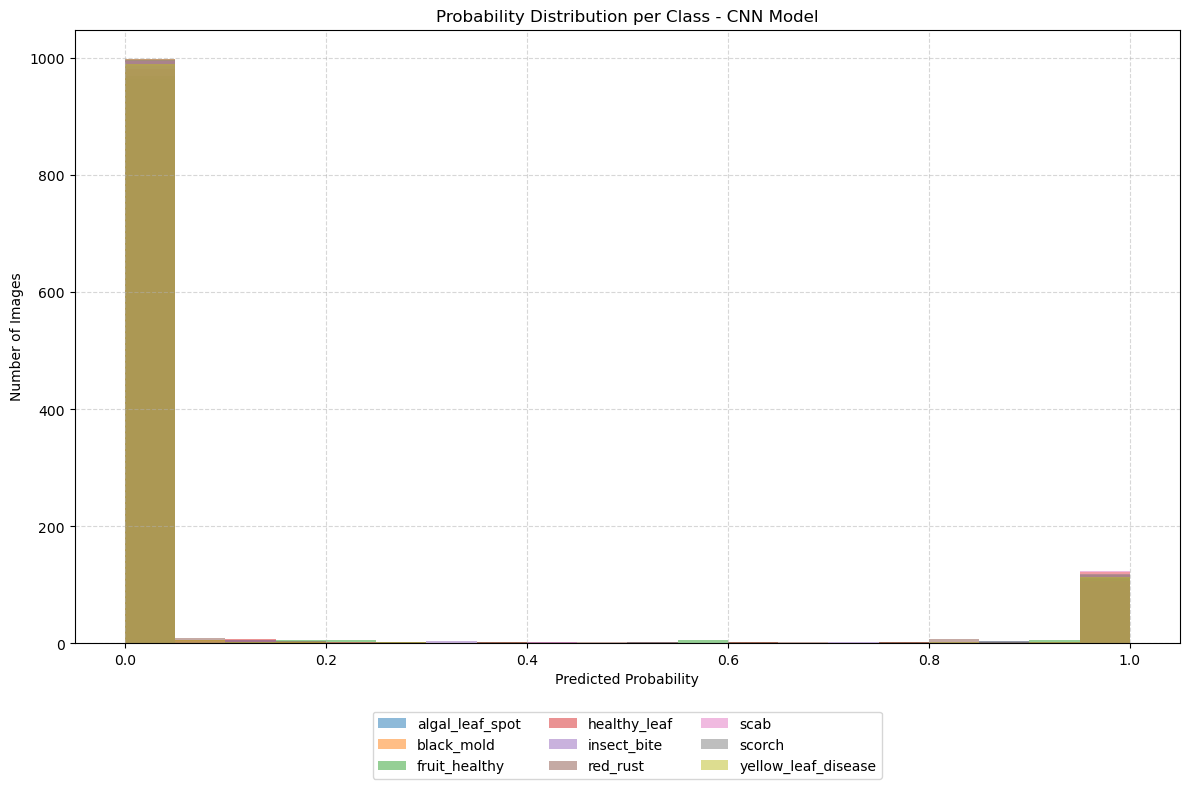

In [14]:
import matplotlib.pyplot as plt

# preds already computed
plt.figure(figsize=(12,8))
for i, class_name in enumerate(class_labels):
    plt.hist(preds[:,i], bins=20, alpha=0.5, label=class_name)

plt.xlabel("Predicted Probability")
plt.ylabel("Number of Images")
plt.title("Probability Distribution per Class - CNN Model")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


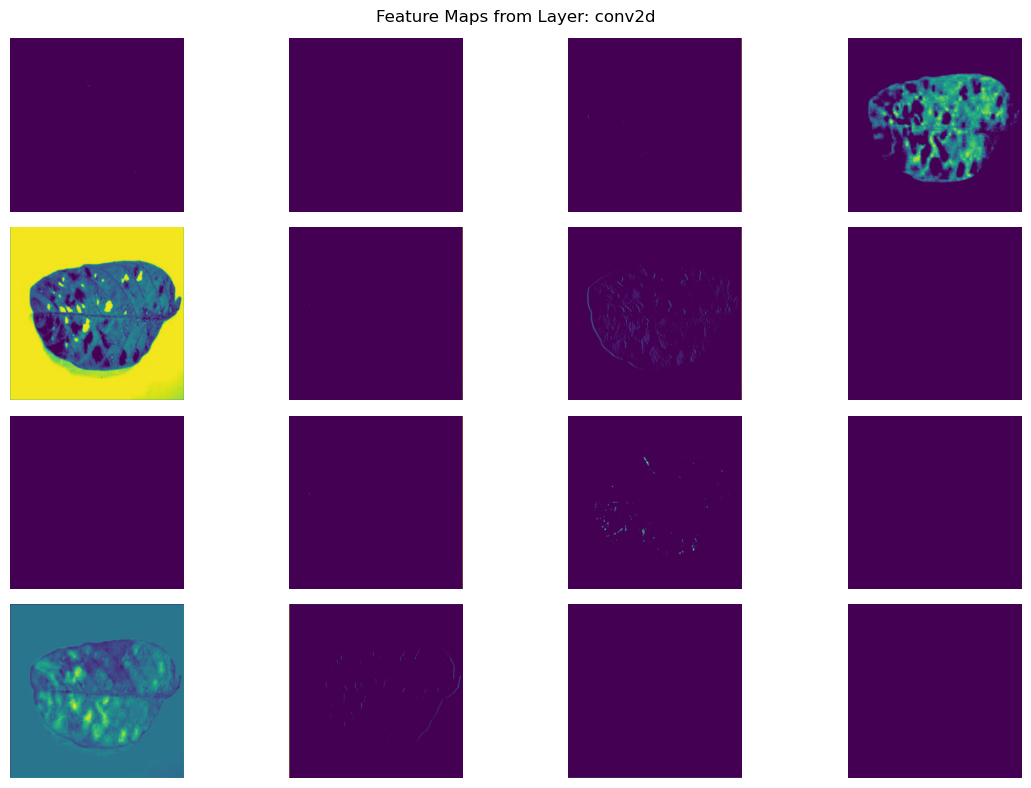

In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# Load one sample image from test set
img_path = r"D:\JU\yoloalldatast4004\cnn\data\test\algal_leaf_spot\algal_leaf_spot0019ba_jpg.rf.7621cedcb925dff4414e2d3afa31b1de_dup433.jpg"
img = image.load_img(img_path, target_size=(img_height, img_width))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

# Choose a convolutional layer (e.g., first Conv2D)
layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][0]
intermediate_layer_model = Model(inputs=model.input,
                                 outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(x)

# Plot first 16 feature maps
num_features = min(16, intermediate_output.shape[-1])
plt.figure(figsize=(12,8))
for i in range(num_features):
    plt.subplot(4,4,i+1)
    plt.imshow(intermediate_output[0,:,:,i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f"Feature Maps from Layer: {layer_name}")
plt.tight_layout()
plt.show()


🔄 Loading model...
✅ Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
Predicted Class: algal_leaf_spot
Probability: 100.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


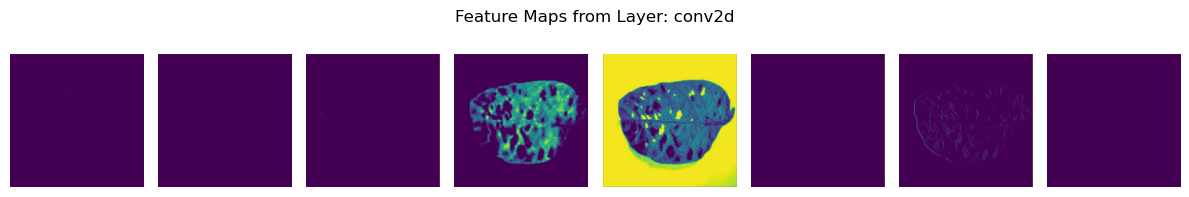

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


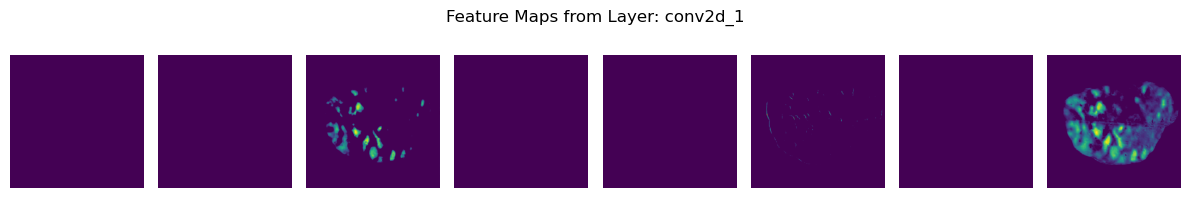

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


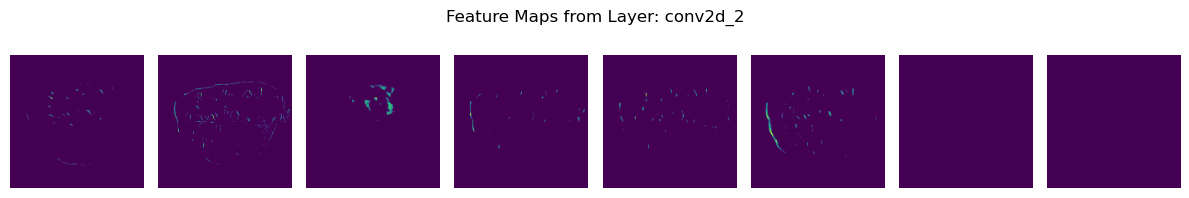

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


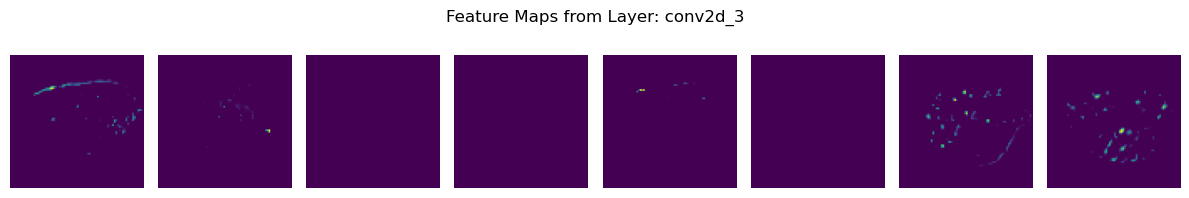

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
img_path = r"D:\JU\yoloalldatast4004\cnn\data\test\algal_leaf_spot\algal_leaf_spot0019ba_jpg.rf.7621cedcb925dff4414e2d3afa31b1de_dup433.jpg"

# ==============================
# CNN Classes
# ==============================
cnn_classes = [
    "algal_leaf_spot", "black_mold", "fruit_healthy", "healthy_leaf",
    "insect_bite", "red_rust", "scab", "scorch", "yellow_leaf_disease"
]

# ==============================
# Parameters
# ==============================
img_height, img_width = 640, 640

# ==============================
# Load Model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Load and Preprocess Image
# ==============================
img = image.load_img(img_path, target_size=(img_height, img_width))
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)  # Shape: (1, 640, 640, 3)

# ==============================
# Predict Class
# ==============================
preds = model.predict(x)
class_idx = np.argmax(preds)
predicted_class = cnn_classes[class_idx]
probability = preds[0][class_idx]

print(f"Predicted Class: {predicted_class}")
print(f"Probability: {probability*100:.2f}%")

# ==============================
# Visualize Feature Maps
# ==============================
conv_layers = [layer.name for layer in model.layers if 'conv' in layer.name]

for layer_name in conv_layers:
    # Create intermediate model to get activations
    intermediate_model = Model(inputs=model.input,
                               outputs=model.get_layer(layer_name).output)
    feature_maps = intermediate_model.predict(x)
    
    # Display first 8 feature maps
    num_features = min(8, feature_maps.shape[-1])
    plt.figure(figsize=(12, 2))
    
    for i in range(num_features):
        plt.subplot(1, num_features, i+1)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis('off')
    
    plt.suptitle(f"Feature Maps from Layer: {layer_name}")
    plt.tight_layout()
    plt.show()


In [20]:
!pip install pydot graphviz



   -------------------- ------------------- 1/2 [graphviz]
   ---------------------------------------- 2/2 [graphviz]



In [22]:
pip install visualkeras




   ---------------------------------------- 2/2 [visualkeras]



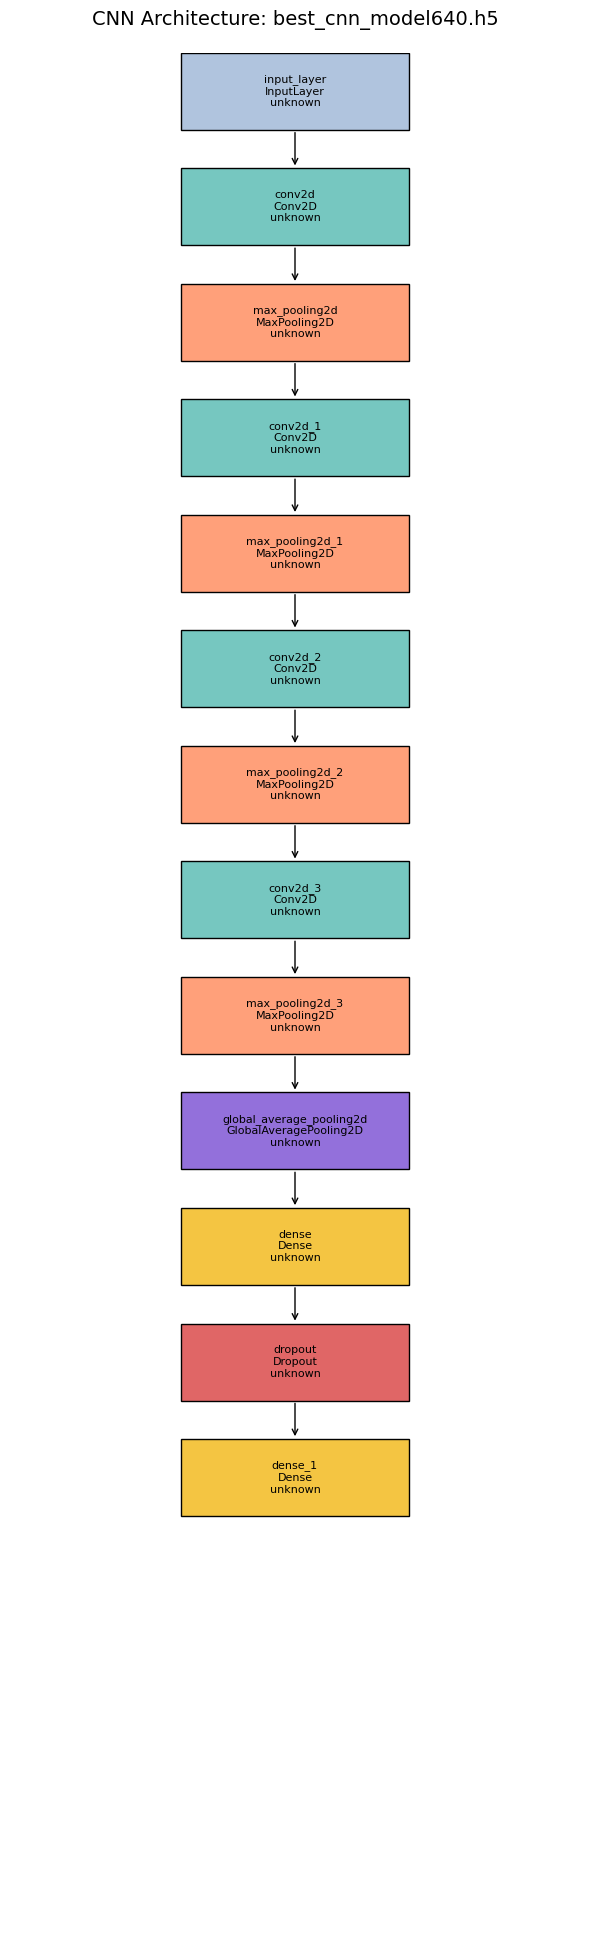

In [27]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load the model
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model640.h5"
model = load_model(model_path)
layers = model.layers

# Color mapping for different layer types
color_map = {
    'Conv2D': '#76c7c0',           # teal
    'MaxPooling2D': '#ffa07a',     # salmon
    'Dense': '#f4c542',            # yellow
    'Dropout': '#e06666',          # red
    'GlobalAveragePooling2D': '#9370db',  # purple
    'InputLayer': '#b0c4de'        # light blue
}

# Figure settings
fig, ax = plt.subplots(figsize=(6, len(layers)*1.5))
ax.axis('off')

y_pos = len(layers) * 1.5  # start from top
x_center = 0.5
layer_boxes = []

# Draw each layer as a colored rectangle
for i, layer in enumerate(layers):
    layer_type = layer.__class__.__name__
    color = color_map.get(layer_type, '#d3d3d3')  # default gray
    output_shape = layer.output_shape if hasattr(layer, 'output_shape') else 'unknown'
    
    # Draw rectangle
    rect = plt.Rectangle((x_center-0.2, y_pos-0.8), 0.4, 0.8, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    
    # Layer name + output shape
    ax.text(x_center, y_pos-0.4, f"{layer.name}\n{layer_type}\n{output_shape}",
            ha='center', va='center', fontsize=8)
    
    layer_boxes.append((x_center, y_pos-0.4))
    
    y_pos -= 1.2  # move down

# Draw arrows connecting layers
for i in range(len(layer_boxes)-1):
    x0, y0 = layer_boxes[i]
    x1, y1 = layer_boxes[i+1]
    ax.annotate('', xy=(x1, y1+0.4), xytext=(x0, y0-0.4),
                arrowprops=dict(arrowstyle='->', color='black'))

# Adjust limits
ax.set_xlim(0, 1)
ax.set_ylim(0, len(layers)*1.5)

# Title
plt.title("CNN Architecture: best_cnn_model640.h5", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


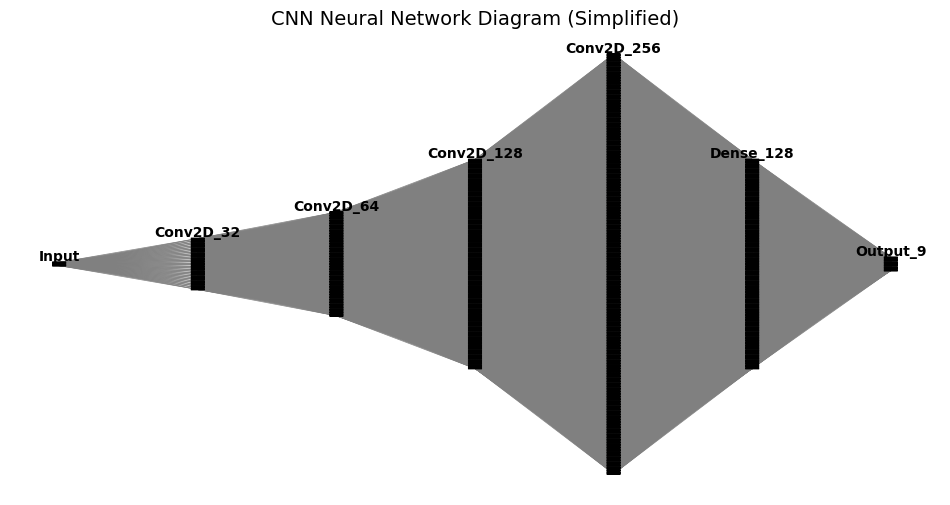

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Simplified layer sizes for visualization
# You can adjust number of neurons to keep diagram clear
layer_sizes = [3, 32, 64, 128, 256, 128, 9]  # Input, Conv1, Conv2, Conv3, Conv4, Dense, Output

fig, ax = plt.subplots(figsize=(12,6))
ax.axis('off')

n_layers = len(layer_sizes)
v_spacing = 1
h_spacing = 2

# Store neuron positions
neurons = []

for i, layer_size in enumerate(layer_sizes):
    x = i * h_spacing
    y_positions = np.linspace(-v_spacing*(layer_size-1)/2, v_spacing*(layer_size-1)/2, layer_size)
    neurons.append((x, y_positions))
    for y in y_positions:
        circle = plt.Circle((x, y), 0.1, color='skyblue', ec='black', zorder=4)
        ax.add_patch(circle)

# Draw connections
for i in range(n_layers-1):
    x0, y0 = neurons[i]
    x1, y1 = neurons[i+1]
    for y_start in y0:
        for y_end in y1:
            ax.plot([x0, x1], [y_start, y_end], color='gray', linewidth=0.5)

# Labels
layer_labels = ['Input', 'Conv2D_32', 'Conv2D_64', 'Conv2D_128', 'Conv2D_256', 'Dense_128', 'Output_9']
for i, (x, _) in enumerate(neurons):
    ax.text(x, v_spacing*layer_sizes[i]/2 + 0.5, layer_labels[i], ha='center', fontsize=10, fontweight='bold')

plt.title("CNN Neural Network Diagram (Simplified)", fontsize=14)
plt.show()


In [29]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Paths
# ==============================
model_path = r"D:\JU\yoloresult\result_model\best_cnn_model256.h5"  # <-- changed model
test_data_dir = r"D:\JU\yoloalldatast4004\cnn\data1\test" # <-- changed model

# ==============================
# Parameters
# ==============================
img_height, img_width = 256, 256  # <-- changed input size for CNN-256
batch_size = 32

# ==============================
# Load model
# ==============================
print("🔄 Loading model...")
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully.")

# ==============================
# Data generator for test set
# ==============================
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# ==============================
# Evaluate model
# ==============================
print("\n🧪 Evaluating model on test images...")
loss, accuracy = model.evaluate(test_generator, verbose=1)

# ==============================
# Print accuracy
# ==============================
print("\n===================================")
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
print(f"📉 Test Loss: {loss:.4f}")
print("===================================")


🔄 Loading model...
✅ Model loaded successfully.
Found 1125 images belonging to 9 classes.


C:\Users\AIC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



🧪 Evaluating model on test images...
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 377ms/step - accuracy: 0.9680 - loss: 0.0869

✅ Test Accuracy: 96.80%
📉 Test Loss: 0.0869
